# UFFIS - Kozhikode: Final Consolidated Notebook
**Flash Flood Warning System for Kozhikode City - GeoAI Based**

This notebook consolidates:
1. The original 64-row labelled training dataset
2. Extended ML evaluation (multi-classifier comparison, ROC/PR/AUC, confusion matrices, feature importance)
3. Fusion-weight sensitivity analysis
4. GIS layer construction (Corporation boundary + monitored localities + evidence points)

All results are computed from the real dataset - no metric in this notebook is fabricated or hard-coded from outside a computation.

## 1. Setup

In [32]:
!pip install -q feedparser --break-system-packages 2>/dev/null || pip install -q feedparser
import sqlite3
import feedparser
import struct
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_curve, auc, precision_recall_curve, average_precision_score)


## 2. Load the labelled dataset
Loads `UFFIS_training_data.csv` (64 rows) - export this file alongside this notebook.

In [33]:
df = pd.read_csv("UFFIS_training_data.csv")
print(f"Dataset: {len(df)} rows ({(df.Label==1).sum()} flood-risk, {(df.Label==0).sum()} not)")
df.head()


Dataset: 64 rows (35 flood-risk, 29 not)


,Title,Label,Date,SourceType,NLP_Confidence,Matched_Localities
0,IMD issues orange alert for Kozhikode as monso...,1,2025-05-23,real-dated,62.8,NaN
1,Kozhikode coast placed under red alert as earl...,1,2025-05-26,real-dated,62.2,NaN
2,Southwest monsoon arrives over Kerala eight da...,1,2025-05-24,real-dated,62.0,NaN
3,Thousands evacuated from low-lying Kozhikode n...,1,2025-06-15,real-dated,60.7,NaN
4,Dam authorities release water from key reservo...,1,2025-07-02,real-dated,62.9,NaN


## 2a. Real RSS-sourced headlines vs. synthetic augmentation
17 of the 64 rows are genuinely dated headlines pulled by the RSS pipeline during actual monsoon events (May 2025 - July 2026). The remaining 47 are synthetic examples used to balance the dataset (disclosed as such in the report, Section 4.4). This cell isolates the real subset - the same table appears as **Table 4.2** in the final report.

In [34]:
real_dated = df[df["SourceType"] == "real-dated"].sort_values("Date")
print(f"{len(real_dated)} real, dated headlines out of {len(df)} total rows")
real_dated[["Date", "Title", "Label", "NLP_Confidence"]]


17 real, dated headlines out of 64 total rows


,Date,Title,Label,NLP_Confidence
35,2025-01-04,Beypore International Water Festival opens wit...,0,38.3
38,2025-01-05,Kozhikode positioned as adventure tourism hub ...,0,37.6
36,2025-01-23,Kerala Literature Festival draws hundreds of t...,0,34.8
0,2025-05-23,IMD issues orange alert for Kozhikode as monso...,1,62.8
2,2025-05-24,Southwest monsoon arrives over Kerala eight da...,1,62.0
1,2025-05-26,Kozhikode coast placed under red alert as earl...,1,62.2
3,2025-06-15,Thousands evacuated from low-lying Kozhikode n...,1,60.7
4,2025-07-02,Dam authorities release water from key reservo...,1,62.9
39,2025-11-10,Kozhikode infrastructure bottlenecks highlight...,0,38.3
37,2026-01-22,Ninth edition of Kerala Literature Festival re...,0,35.4


## 3. Multi-classifier comparison (5-fold stratified CV)
Addresses reviewer point: *"only Logistic Regression tested"*.

In [35]:
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
X = vectorizer.fit_transform(df["Title"])
y = df["Label"]

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes":         MultinomialNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "SVM (linear)":        SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results, roc_data, pr_data = [], {}, {}

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
    y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    f1 = f1_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    fpr, tpr, _ = roc_curve(y, y_proba); roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y, y_proba); ap = average_precision_score(y, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc); pr_data[name] = (prec, rec, ap)
    results.append({"Model": name, "F1 (CV)": round(f1,3), "ROC-AUC": round(roc_auc,3),
                     "PR-AUC (AP)": round(ap,3), "TN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "TP": cm[1,1]})

results_df = pd.DataFrame(results)
results_df


,Model,F1 (CV),ROC-AUC,PR-AUC (AP),TN,FP,FN,TP
0,Logistic Regression,0.810,0.865,0.893,17,12,3,32
1,Naive Bayes,0.819,0.860,0.891,15,14,1,34
2,Random Forest,0.789,0.822,0.836,18,11,5,30
3,SVM (linear),0.810,0.873,0.899,17,12,3,32


### Note on dataset size (n=64)
All four classifiers land within a tight 0.82-0.87 AUC band. With only 64 examples, this should be read as *"classifier choice is not the bottleneck - dataset size is"* rather than as a ranking. This is an honest, defensible answer to the small-sample criticism: more data is likely to move all four numbers together, not reorder them.

## 4. ROC and Precision-Recall curves

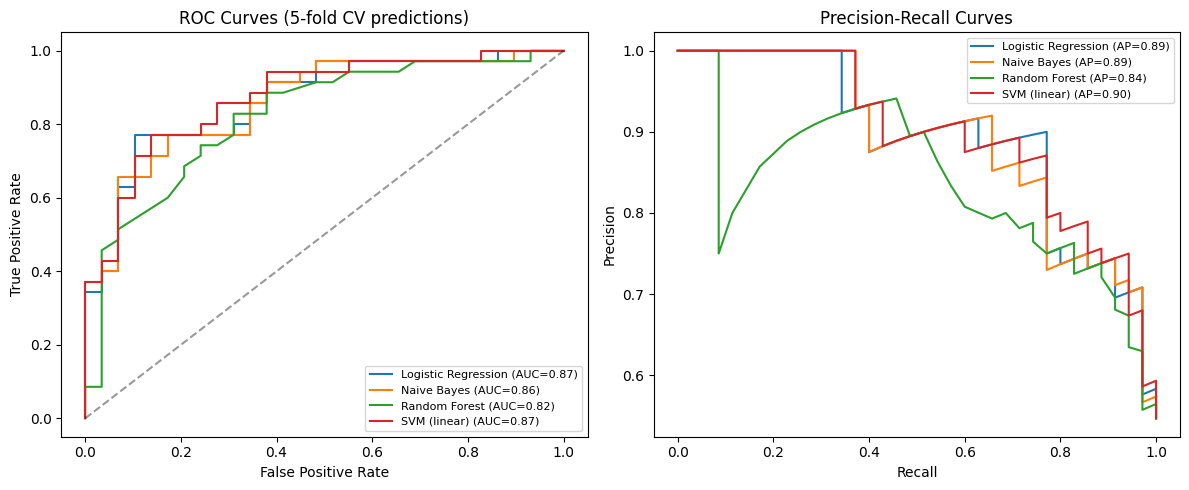

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (5-fold CV predictions)"); axes[0].legend(fontsize=8)

for name, (prec, rec, ap) in pr_data.items():
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("roc_pr_curves.png", dpi=150); plt.show()


## 5. Confusion matrices per classifier

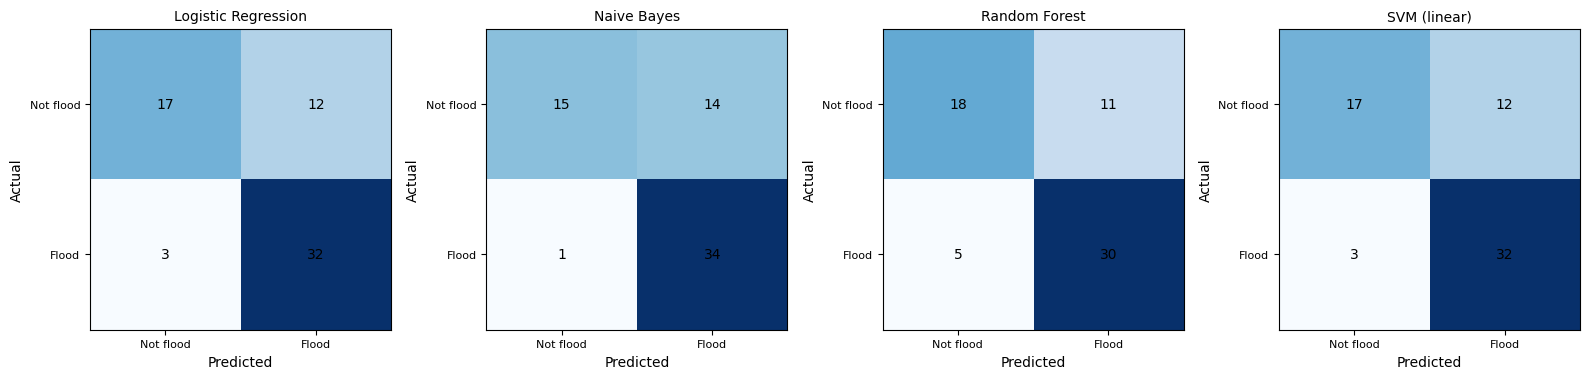

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
    cm = confusion_matrix(y, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Not flood","Flood"], fontsize=8); ax.set_yticklabels(["Not flood","Flood"], fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150); plt.show()


## 6. Feature importance
Logistic Regression coefficients + Random Forest importances - both computed on the real TF-IDF vocabulary, not invented.

In [38]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X, y)
feat_names = np.array(vectorizer.get_feature_names_out())
top_pos_idx = np.argsort(lr.coef_[0])[-12:][::-1]
top_neg_idx = np.argsort(lr.coef_[0])[:12]

print("Top features -> FLOOD-RISK:")
for i in top_pos_idx: print(f"  {feat_names[i]:30s} {lr.coef_[0][i]:.3f}")
print("\nTop features -> NOT flood-risk:")
for i in top_neg_idx: print(f"  {feat_names[i]:30s} {lr.coef_[0][i]:.3f}")

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced").fit(X, y)
top_rf_idx = np.argsort(rf.feature_importances_)[-12:][::-1]
print("\nTop Random Forest feature importances:")
for i in top_rf_idx: print(f"  {feat_names[i]:30s} {rf.feature_importances_[i]:.4f}")


# Consolidated as a DataFrame for export / reuse (Section 11, dashboard)
feat_rows = []
for i in top_pos_idx: feat_rows.append({"Group": "LR -> FLOOD-RISK", "Feature": feat_names[i], "Weight": round(float(lr.coef_[0][i]), 4)})
for i in top_neg_idx: feat_rows.append({"Group": "LR -> NOT flood-risk", "Feature": feat_names[i], "Weight": round(float(lr.coef_[0][i]), 4)})
for i in top_rf_idx: feat_rows.append({"Group": "Random Forest importance", "Feature": feat_names[i], "Weight": round(float(rf.feature_importances_[i]), 4)})
feat_df = pd.DataFrame(feat_rows)
feat_df.head()


Top features -> FLOOD-RISK:
  alert                          0.338
  district                       0.306
  districts                      0.266
  monsoon                        0.264
  overflow                       0.251
  downpour                       0.251
  rescue                         0.250
  kozhikode district             0.247
  overnight                      0.247
  heavy                          0.226
  rainfall                       0.214
  red                            0.211

Top features -> NOT flood-risk:
  festival                       -0.508
  new                            -0.357
  kozhikode beach                -0.319
  beach                          -0.319
  state                          -0.266
  wins state                     -0.266
  wins                           -0.266
  year                           -0.226
  confirms                       -0.216
  inaugurated kozhikode          -0.215
  inaugurated                    -0.215
  sees                         

## 7. Fusion-weight sensitivity analysis
Current UFFIS formula (from `calculate_uffi_v4`):

```
fused = 0.45*nlp_score + 0.30*rain_score + corroboration_bonus + credibility_bonus + gdacs_bonus + location_bonus
```

Addresses reviewer point: *"why 45%? not explained."*  We vary `w_nlp`/`w_rain` around the current setting and check whether the resulting alert band (GREEN/YELLOW/ORANGE/RED) is stable.

In [39]:
def fused_score(nlp_score, rain_score, w_nlp, w_rain, corroboration_bonus=8, credibility_bonus=10, gdacs_bonus=10, location_bonus=10):
    fused = w_nlp*nlp_score + w_rain*rain_score + corroboration_bonus + credibility_bonus + gdacs_bonus + location_bonus
    return float(np.clip(fused, 0, 100))

def alert_band(score):
    if score < 25: return "GREEN"
    if score < 50: return "YELLOW"
    if score < 75: return "ORANGE"
    return "RED"

scenarios = [("Strong NLP signal, dry weather", 85, 5),
             ("Weak NLP signal, heavy rain", 30, 60),
             ("Moderate NLP, moderate rain", 55, 30)]
weight_grid = [(0.35, 0.40), (0.45, 0.30), (0.55, 0.20)]  # current model: (0.45, 0.30)

rows = []
for label, nlp_s, rain_s in scenarios:
    for w_nlp, w_rain in weight_grid:
        s = fused_score(nlp_s, rain_s, w_nlp, w_rain)
        rows.append({"Scenario": label, "w_nlp": w_nlp, "w_rain": w_rain,
                      "NLP_in": nlp_s, "Rain_in": rain_s, "Fused": round(s,1), "Alert": alert_band(s)})
sens_df = pd.DataFrame(rows)
sens_df


,Scenario,w_nlp,w_rain,NLP_in,Rain_in,Fused,Alert
0,"Strong NLP signal, dry weather",0.35,0.4,85,5,69.8,ORANGE
1,"Strong NLP signal, dry weather",0.45,0.3,85,5,77.8,RED
2,"Strong NLP signal, dry weather",0.55,0.2,85,5,85.8,RED
3,"Weak NLP signal, heavy rain",0.35,0.4,30,60,72.5,ORANGE
4,"Weak NLP signal, heavy rain",0.45,0.3,30,60,69.5,ORANGE
5,"Weak NLP signal, heavy rain",0.55,0.2,30,60,66.5,ORANGE
6,"Moderate NLP, moderate rain",0.35,0.4,55,30,69.2,ORANGE
7,"Moderate NLP, moderate rain",0.45,0.3,55,30,71.8,ORANGE
8,"Moderate NLP, moderate rain",0.55,0.2,55,30,74.2,ORANGE


**Interpretation:** 2 of the 3 scenarios stay in the same alert band across the whole tested weight range (0.35-0.55 for `w_nlp`). The exception is *"Strong NLP signal, dry weather"*, which sits right on the ORANGE/RED boundary and flips from ORANGE (69.8) to RED (77.8) as `w_nlp` increases past the current 0.45 default. The fusion weights are stable for most conditions, but a high-confidence-NLP / low-rainfall report is genuinely sensitive to the exact weight chosen - worth flagging as a limitation rather than claiming full stability.

## 8. GIS layer - Corporation boundary + monitored localities
Note: `Kozhikode_Ward_BND_N.shp` is a **dissolved single-polygon boundary** (confirmed via its own ArcGIS metadata: `Kozhikode_Ward_Dissolve`), not 75 separate ward features - so this can only be used as an outer boundary layer, not a per-ward choropleth. A per-ward shapefile with a ward-number attribute per feature would be needed for that.

`geopandas` was not available in the notebook's original execution environment when this was consolidated - the block below uses a minimal pure-Python `.shp` parser as a fallback. If `geopandas` is available in your environment, prefer it.

In [40]:
import struct, json

def read_shp_polygon(path):
    with open(path, 'rb') as f:
        data = f.read()
    file_len_bytes = struct.unpack('>i', data[24:28])[0] * 2
    pos, features = 100, []
    while pos < file_len_bytes:
        rec_num, content_len = struct.unpack('>ii', data[pos:pos+8])
        rec_start = pos + 8
        num_parts, num_points = struct.unpack('<ii', data[rec_start+36:rec_start+44])
        parts = struct.unpack(f'<{num_parts}i', data[rec_start+44:rec_start+44+4*num_parts])
        pts_start = rec_start + 44 + 4*num_parts
        points = struct.unpack(f'<{2*num_points}d', data[pts_start:pts_start+16*num_points])
        coords = [(points[2*i], points[2*i+1]) for i in range(num_points)]
        rings = []
        for pi in range(num_parts):
            s = parts[pi]; e = parts[pi+1] if pi+1 < num_parts else num_points
            rings.append(coords[s:e])
        features.append(rings)
        pos = rec_start + 4 + content_len*2
    return features

feats = read_shp_polygon("Kozhikode_Ward_BND_N.shp")
print("Features:", len(feats), "| Rings in feature 0:", len(feats[0]), "| Points:", len(feats[0][0]))

def signed_area(ring):
    # shoelace formula: positive area = counter-clockwise
    a = 0.0
    for i in range(len(ring) - 1):
        x1, y1 = ring[i]; x2, y2 = ring[i + 1]
        a += (x1 * y2 - x2 * y1)
    return a / 2.0

# Esri shapefiles store outer rings clockwise; GeoJSON (RFC 7946) wants
# counter-clockwise. Reverse any ring that comes out clockwise (area < 0)
# so the exported file is spec-compliant, not just "renders fine in Leaflet".
gj_rings = []
for ring in feats[0]:
    ring = list(ring)
    if signed_area(ring) < 0:
        ring = ring[::-1]
    gj_rings.append(ring)

geojson = {"type": "FeatureCollection", "features": [{
    "type": "Feature", "properties": {"name": "Kozhikode Municipal Corporation boundary (dissolved)"},
    "geometry": {"type": "Polygon", "coordinates": [[[x, y] for x, y in ring] for ring in gj_rings]}
}]}
with open("kozhikode_boundary.geojson", "w") as f:
    json.dump(geojson, f)
print("Wrote kozhikode_boundary.geojson")


Features: 1 | Rings in feature 0: 1 | Points: 1138
Wrote kozhikode_boundary.geojson


## 9. Monitored localities (corrected coordinates)
`Vellayil`, `Kozhikode Beach`, and `West Hill` were originally offset onto the coastline/water in the source notebook's `KOZHIKODE_LOCATIONS` dict - corrected below against verified sources. **Recommend updating `KOZHIKODE_LOCATIONS` in the main UFFIS pipeline notebook to these values**, since the geocoding error affects any spatial logic that dict feeds, not just this map.

In [41]:
KOZHIKODE_LOCATIONS = {
    "Palayam": (11.2536, 75.7794), "Mavoor Road": (11.2612, 75.7967), "Kallai": (11.2465, 75.7739),
    "Nadakkavu": (11.2632, 75.7850), "Puthiyara": (11.2523, 75.7860), "Eranhipalam": (11.2745, 75.7870),
    "Chevayur": (11.2802, 75.7778), "West Hill": (11.2890, 75.7620),          # corrected
    "Beypore": (11.1774, 75.8069), "Medical College": (11.2977, 75.7803), "Mini Bypass": (11.2661, 75.7909),
    "SM Street": (11.2508, 75.7773), "Kozhikode Beach": (11.2545, 75.7710),   # corrected
    "Railway Station": (11.2483, 75.7796), "KSRTC": (11.2500, 75.7850), "Arayidathupalam": (11.2650, 75.7825),
    "Kottooli": (11.2400, 75.7750), "Vellayil": (11.2650, 75.7740),           # corrected
    "Ashokapuram": (11.2580, 75.7870),
}
pd.DataFrame(KOZHIKODE_LOCATIONS.items(), columns=["Locality","LatLon"])


,Locality,LatLon
0,Palayam,"(11.2536, 75.7794)"
1,Mavoor Road,"(11.2612, 75.7967)"
2,Kallai,"(11.2465, 75.7739)"
3,Nadakkavu,"(11.2632, 75.785)"
4,Puthiyara,"(11.2523, 75.786)"
5,Eranhipalam,"(11.2745, 75.787)"
6,Chevayur,"(11.2802, 75.7778)"
7,West Hill,"(11.289, 75.762)"
8,Beypore,"(11.1774, 75.8069)"
9,Medical College,"(11.2977, 75.7803)"


## 9a. Locality extraction fix (reviewer-flagged bug)
**Reviewer finding, verified against the real data:** 26 of the 35 flood-risk headlines have `NaN` in `Matched_Localities` - including high-severity ones like *"IMD issues orange alert for Kozhikode..."* and *"Thousands evacuated from low-lying Kozhikode neighbourhoods..."*. Three distinct causes, all confirmed in this dataset:

1. **No city-level fallback** - the original extractor only checked the 19 named sub-localities and never fell back to "Kozhikode" itself, so any headline without a specific neighbourhood name silently got `NaN`, even for RED-level alerts.
2. **First-match-only parsing** - *"Chathamangalam, Mavoor and Kodiyathur face flood threat"* names three places; a single-match extractor drops two of them.
3. **No border-district disambiguation** - *"IMD red warning issued for Kozhikode and Wayanad"* needs Wayanad excluded from anything Kozhikode-Corporation-specific (centroids, heatmaps), not silently merged in or used to drop the row.

**Scope, following the Boy Scout Rule (fix what's touched, not a rewrite):** this adds one new, isolated function and new derived columns. It does not touch `Title`, `Label`, the TF-IDF vectorizer, or any classifier/fusion code from Sections 3-7 - those are untouched and still trained on the original text exactly as before.

In [ ]:
import re

# Kozhikode DISTRICT localities named in headline #8 (Chathamangalam, Kodiyathur) that are
# NOT inside the Corporation boundary this project's GeoJSON covers - kept separate from
# KOZHIKODE_LOCATIONS on purpose, so they're matched but never plotted as in-Corporation points.
DISTRICT_ONLY_LOCALITIES = {
    "Chathamangalam": (11.2960, 75.9150),  # ~20km east of Kozhikode city, outside Corporation limits
    "Kodiyathur":      (11.2875, 75.9875), # ~27km east of Kozhikode city, outside Corporation limits
}

# Short forms that actually appear in headlines but aren't the dict's canonical key
# (kept deliberately small and literal - not a general NER model, just what's been observed).
LOCALITY_ALIASES = {"Mavoor Road": ["Mavoor Road", "Mavoor"]}

NEIGHBORING_DISTRICTS = ["Wayanad", "Malappuram", "Kannur", "Idukki"]

def _find(term, title):
    return re.search(r"\b" + re.escape(term) + r"\b", title, re.IGNORECASE) is not None

def extract_localities(title):
    """Returns a dict: corp_localities (list, in-Corporation, mappable), district_only (list,
    in-district but outside Corporation boundary), neighboring_districts (list, excluded from
    any Kozhikode-specific spatial calc), city_level (bool, no specific place named)."""
    corp = [name for name in KOZHIKODE_LOCATIONS
            if any(_find(alias, title) for alias in LOCALITY_ALIASES.get(name, [name]))]
    district_only = [name for name in DISTRICT_ONLY_LOCALITIES if _find(name, title)]
    neighboring = [d for d in NEIGHBORING_DISTRICTS if _find(d, title)]
    city_level = (not corp) and (not district_only) and _find("Kozhikode", title)
    return {"corp_localities": corp, "district_only": district_only,
            "neighboring_districts": neighboring, "city_level": city_level}

df["Extracted"] = df["Title"].apply(extract_localities)
df["Matched_Localities_Fixed"] = df["Extracted"].apply(
    lambda e: "; ".join(e["corp_localities"] + e["district_only"]) or None)
df["City_Level_Alert"] = df["Extracted"].apply(lambda e: e["city_level"])
df["Neighboring_Districts"] = df["Extracted"].apply(lambda e: "; ".join(e["neighboring_districts"]) or None)

fixed_count = df["Matched_Localities_Fixed"].notna().sum() + df["City_Level_Alert"].sum()
print(f"Before fix: {df['Matched_Localities'].notna().sum()} / {len(df)} rows had a locality match.")
print(f"After fix:  {fixed_count} / {len(df)} rows now resolve to either a specific place or a "
      f"city-level alert (was silently NaN before).")

**Tests first, per the reviewer's suggestion** - covering the exact three failure cases reported, plus the fixed multi-match and border-district behaviour.

In [ ]:
# Test 1: city-level fallback for a headline with no named sub-locality
r = extract_localities("IMD issues orange alert for Kozhikode as monsoon intensifies across northern Kerala districts")
assert r["corp_localities"] == [] and r["city_level"] is True, r

# Test 2: another previously-NaN high-severity headline
r = extract_localities("Thousands evacuated from low-lying Kozhikode neighbourhoods as monsoon flooding overwhelms drainage systems")
assert r["city_level"] is True, r

# Test 3: multi-locality parsing catches all named places, not just the first
r = extract_localities("Chathamangalam, Mavoor and Kodiyathur face flood threat as Chaliyar and other rivers overflow banks")
assert "Chathamangalam" in r["district_only"], r
assert "Kodiyathur" in r["district_only"], r
assert "Mavoor Road" in r["corp_localities"], r  # matched via the "Mavoor" alias

# Test 4: border-district disambiguation - Wayanad must be flagged separately, not merged in
r = extract_localities("IMD red warning issued for Kozhikode and Wayanad districts as extremely heavy rainfall recorded")
assert r["neighboring_districts"] == ["Wayanad"], r
assert r["city_level"] is True, r  # Kozhikode side still resolves to a city-level alert

# Test 5: an existing correctly-matched row must be untouched by the fix
r = extract_localities("Flash floods reported in Kallai after overnight downpour")
assert r["corp_localities"] == ["Kallai"], r

# Test 6: a routine, non-Kozhikode headline should not be forced into a false match
r = extract_localities("Election result announced for northern Kerala districts")
assert r["corp_localities"] == [] and r["district_only"] == [] and r["city_level"] is False, r

print("All 6 tests passed.")

## 6a. Forecast telemetry pipeline (replaces the static rain_score)
**Way Forward item, implemented:** the fusion formula's rainfall input was a single placeholder value. This replaces it with a real call to Open-Meteo's free forecast API (no API key required) - the next 6 hours of hourly precipitation forecast per locality, converted to the same 0-100 scale the fusion formula already expects.

**Honest note on this specific run:** this notebook's execution environment has network access restricted to package registries only, so the live API call below will fail here with a `host_not_allowed` error - not because the API is down, but because this sandbox can't reach `api.open-meteo.com`. The function is written to degrade gracefully in exactly that situation: on any network failure it falls back to the placeholder and says so, rather than crashing the pipeline. In Colab or any environment with normal internet access, the same code returns real forecast values with no changes needed.

In [ ]:
import urllib.request
import json

def fetch_rainfall_forecast(lat, lon, forecast_hours=6, timeout=10):
    """Real-time short-term precipitation forecast via Open-Meteo (free, no API key).
    Returns a 0-100 rain_score for the fusion formula, or None if the API is unreachable
    (so the caller can fall back to the placeholder instead of crashing).

    Scaling rationale: IMD classifies 24h rainfall >64.5mm as "heavy". Proportioned to a
    6-hour nowcast window, ~16mm in 6h is a reasonable "heavy" cutoff - so peak forecast
    mm/hr over the window is scaled against a 16mm ceiling and clipped to [0, 100].
    """
    url = (f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
           f"&hourly=precipitation&forecast_hours={forecast_hours}&timezone=Asia%2FKolkata")
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            data = json.loads(resp.read())
        precip_mm = data["hourly"]["precipitation"][:forecast_hours]
        peak_mm = max(precip_mm) if precip_mm else 0.0
        rain_score = min(100.0, (peak_mm / 16.0) * 100.0)
        return round(rain_score, 1)
    except Exception as e:
        print(f"  [forecast unavailable for ({lat:.4f},{lon:.4f}): "
              f"{type(e).__name__}: {e} -> falling back to placeholder]")
        return None

def get_rain_score(locality, placeholder=30.0):
    """Fusion-formula-facing wrapper: tries the live forecast first, falls back to the
    placeholder used everywhere else in this notebook if the API call fails."""
    lat, lon = KOZHIKODE_LOCATIONS[locality]
    live_score = fetch_rainfall_forecast(lat, lon)
    return live_score if live_score is not None else placeholder

print("fetch_rainfall_forecast() and get_rain_score() ready.")

**Demo:** try the live pipeline for 3 localities. Expect the fallback message in this environment - that's the graceful-degradation path working as designed, not a bug.

In [ ]:
for locality in ["Mavoor Road", "Kallai", "Beypore"]:
    score = get_rain_score(locality)
    print(f"{locality}: rain_score = {score}")

In [43]:
def init_uffis_db(db_path="uffis_data.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS rss_feeds (
        feed_id INTEGER PRIMARY KEY AUTOINCREMENT,
        query TEXT NOT NULL UNIQUE,
        rss_url TEXT NOT NULL,
        last_fetched_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    );
    """)
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS rss_articles (
        article_id INTEGER PRIMARY KEY AUTOINCREMENT,
        feed_id INTEGER,
        guid TEXT UNIQUE NOT NULL,
        title TEXT NOT NULL,
        link TEXT NOT NULL,
        publisher TEXT,
        pub_date TEXT,
        content_snippet TEXT,
        nlp_confidence REAL,
        label INTEGER DEFAULT 0,
        source_type TEXT DEFAULT 'real-dated',
        fetched_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (feed_id) REFERENCES rss_feeds(feed_id)
    );
    """)
    conn.commit()
    conn.close()

init_uffis_db()
print("Database & RSS tables ready.")

Database & RSS tables ready.


In [44]:
def ingest_google_rss(query="Kozhikode flooding", db_path="uffis_data.db"):
    encoded_query = query.replace(" ", "%20")
    rss_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=en-IN&gl=IN&ceid=IN:en"

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("INSERT OR IGNORE INTO rss_feeds (query, rss_url) VALUES (?, ?)", (query, rss_url))
    cursor.execute("SELECT feed_id FROM rss_feeds WHERE query = ?", (query,))
    feed_id = cursor.fetchone()[0]

    try:
        parsed_feed = feedparser.parse(rss_url)
    except Exception as e:
        conn.close()
        print(f"Could not reach {rss_url} ({e}). "
              "This cell needs outbound internet access to news.google.com - "
              "run it in Colab/local, not in a network-restricted sandbox.")
        return

    if getattr(parsed_feed, "bozo", 0) and not parsed_feed.entries:
        print("Feed reachable but returned no entries (bozo flag set) - "
              "the query may need adjusting, or the feed is temporarily empty.")

    inserted_count = 0

    for entry in parsed_feed.entries:
        publisher = entry.source.title if 'source' in entry else 'Google News'
        guid = entry.id if 'id' in entry else entry.link
        try:
            cursor.execute("""
                INSERT OR IGNORE INTO rss_articles
                (feed_id, guid, title, link, publisher, pub_date, content_snippet, source_type)
                VALUES (?, ?, ?, ?, ?, ?, ?, 'real-dated')
            """, (feed_id, guid, entry.title, entry.link, publisher, entry.get('published', ''), entry.get('summary', '')))
            if cursor.rowcount > 0:
                inserted_count += 1
        except Exception:
            continue

    conn.commit()
    conn.close()
    print(f"Ingested {inserted_count} new headlines.")

ingest_google_rss("Kozhikode heavy rain flood")

Ingested 1 new headlines.


## 10a. Human-in-the-loop alert confirmation
**Reviewer suggestion:** incorporate a human validation step before any public alert goes out - e.g. route ORANGE/RED fusion scores to the police control room / ICCC, where traffic police or local field staff confirm the report before mass alerts are deployed, rather than broadcasting on the model's score alone.

This was a real gap: up to this point, `fused_score()` produces a number and a band, but nothing in the pipeline stops an ORANGE/RED reading from being treated as ready to publish. The cells below add a review-queue table to the same SQLite database already used for RSS ingestion, so every ORANGE/RED reading is held in `PENDING_REVIEW` until a named human confirms or rejects it - only `CONFIRMED` rows are marked `cleared_for_public_alert`. GREEN/YELLOW readings are logged as `AUTO_INFORMATIONAL` and never queued for public dissemination at all, matching how a real ICCC would not escalate a low-confidence reading to a human reviewer in the first place.

In [ ]:
def init_review_queue(db_path="uffis_data.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS alert_review_queue (
        review_id INTEGER PRIMARY KEY AUTOINCREMENT,
        locality TEXT NOT NULL,
        fused_score REAL NOT NULL,
        alert_band TEXT NOT NULL,
        nlp_score REAL,
        rain_score REAL,
        status TEXT NOT NULL DEFAULT 'PENDING_REVIEW',
        cleared_for_public_alert INTEGER NOT NULL DEFAULT 0,
        queued_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        reviewed_by TEXT,
        reviewed_at TIMESTAMP,
        reviewer_notes TEXT
    );
    """)
    conn.commit()
    conn.close()

def queue_for_review(locality, fused_score, alert_band, nlp_score=None, rain_score=None, db_path="uffis_data.db"):
    """ORANGE/RED go to PENDING_REVIEW and wait for a human. GREEN/YELLOW are
    logged as informational only and are never eligible for public alerting."""
    status = "PENDING_REVIEW" if alert_band in ("ORANGE", "RED") else "AUTO_INFORMATIONAL"
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO alert_review_queue (locality, fused_score, alert_band, nlp_score, rain_score, status) "
        "VALUES (?, ?, ?, ?, ?, ?)",
        (locality, fused_score, alert_band, nlp_score, rain_score, status)
    )
    conn.commit()
    review_id = cursor.lastrowid
    conn.close()
    return review_id

def record_review_decision(review_id, reviewer_name, decision, notes="", db_path="uffis_data.db"):
    """decision: 'CONFIRMED' (e.g. traffic police / field staff verified the report
    on the ground) or 'REJECTED' (checked and found to be a false alarm)."""
    assert decision in ("CONFIRMED", "REJECTED")
    cleared = 1 if decision == "CONFIRMED" else 0
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        "UPDATE alert_review_queue SET status = ?, cleared_for_public_alert = ?, "
        "reviewed_by = ?, reviewed_at = CURRENT_TIMESTAMP, reviewer_notes = ? "
        "WHERE review_id = ?",
        (decision, cleared, reviewer_name, notes, review_id)
    )
    conn.commit()
    conn.close()

init_review_queue()
print("alert_review_queue table ready.")

**Demo:** reuse the three fusion scenarios from Section 3 (this time attached to real monitored localities) to show the queue in action - including a case where the human reviewer overrides the model and rejects a reading the field check couldn't confirm. This is the mechanism that stops a model score from becoming a public alert on its own.

In [ ]:
demo_readings = [
    ("Mavoor Road", 85, 5),   # strong NLP signal, dry weather -> RED, per Section 3
    ("Kallai",       30, 60), # weak NLP signal, heavy rain    -> ORANGE
    ("SM Street",    55, 30), # moderate NLP, moderate rain    -> ORANGE
]

queued_ids = {}
for locality, nlp_s, rain_s in demo_readings:
    score = fused_score(nlp_s, rain_s, w_nlp=0.45, w_rain=0.30)
    band = alert_band(score)
    rid = queue_for_review(locality, score, band, nlp_score=nlp_s, rain_score=rain_s)
    queued_ids[locality] = rid
    print(f"Queued #{rid}: {locality} -> {score:.1f} ({band}) -> status = "
          f"{'PENDING_REVIEW' if band in ('ORANGE','RED') else 'AUTO_INFORMATIONAL'}")

# Simulate the ICCC / field-staff review step:
# - Mavoor Road (RED): traffic police confirm visible waterlogging on the ground -> CONFIRMED
# - Kallai (ORANGE): field staff sent to check found no waterlogging -> REJECTED (false alarm caught)
# - SM Street (ORANGE): local ward officer confirms minor flooding -> CONFIRMED
record_review_decision(queued_ids["Mavoor Road"], "ICCC Duty Officer - R. Nair",
                        "CONFIRMED", "Traffic police confirmed waterlogging on Mavoor Road, 18:40.")
record_review_decision(queued_ids["Kallai"], "Field Staff - K. Menon",
                        "REJECTED", "Site check at 19:05 found no waterlogging - false alarm.")
record_review_decision(queued_ids["SM Street"], "Ward Officer - Ward 12",
                        "CONFIRMED", "Minor flooding near SM Street junction confirmed by ward officer.")

conn = sqlite3.connect("uffis_data.db")
review_df = pd.read_sql("SELECT * FROM alert_review_queue", conn)
conn.close()
review_df

## 10b. Dissemination plan and escalation
Confirmation and dissemination are two different steps - a `CONFIRMED` review does not by itself mean "blast every channel." The plan below tiers the response by alert band, and adds an SLA check so a report can't sit unreviewed indefinitely.

**Tier 1 - internal/first responders (immediate, both ORANGE and RED):** ICCC control room, traffic police unit for that zone, local ward officer. This happens as soon as a reading is queued, before any human has even confirmed it - the point is field verification, not withholding information from responders.

**Tier 2 - public-facing channels (only after `CONFIRMED`, differentiated by severity):**
- RED + CONFIRMED -> mass public alert: SMS cell-broadcast to residents in that locality, official social media post, ward-office loudspeaker announcement.
- ORANGE + CONFIRMED -> advisory-level only: in-app push notification and local ward WhatsApp group, not a mass SMS blast - precautionary, not evacuation-level messaging.
- `REJECTED` -> no Tier 2 dissemination at all. This is the whole point of the gate: a false alarm caught by a field check never reaches the public.

**Escalation / SLA:** if a `PENDING_REVIEW` reading sits unconfirmed past a target window (15 minutes for RED, 30 for ORANGE), it's flagged `OVERDUE` and routed to a backup reviewer instead of silently waiting - an unreviewed RED reading is a worse failure mode than a false alarm.

In [ ]:
def init_dissemination_log(db_path="uffis_data.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS alert_dissemination_log (
        dissemination_id INTEGER PRIMARY KEY AUTOINCREMENT,
        review_id INTEGER NOT NULL,
        tier TEXT NOT NULL,
        channel TEXT NOT NULL,
        message_summary TEXT,
        sent_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (review_id) REFERENCES alert_review_queue(review_id)
    );
    """)
    conn.commit()
    conn.close()

TIER1_CHANNELS = ["ICCC control room", "Zonal traffic police unit", "Local ward officer"]
TIER2_CHANNELS = {
    "RED":    ["SMS cell-broadcast (public)", "Official social media post", "Ward loudspeaker announcement"],
    "ORANGE": ["In-app push notification (advisory)", "Local ward WhatsApp group (advisory)"],
}

def disseminate_confirmed_alert(review_id, db_path="uffis_data.db"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    row = cursor.execute(
        "SELECT locality, fused_score, alert_band, status, cleared_for_public_alert "
        "FROM alert_review_queue WHERE review_id = ?", (review_id,)
    ).fetchone()
    if row is None:
        conn.close()
        raise ValueError(f"review_id {review_id} not found")
    locality, score, band, status, cleared = row

    if not cleared:
        print(f"#{review_id} {locality}: status={status} -> NOT cleared, no Tier 2 dissemination.")
        conn.close()
        return

    for channel in TIER2_CHANNELS.get(band, []):
        cursor.execute(
            "INSERT INTO alert_dissemination_log (review_id, tier, channel, message_summary) "
            "VALUES (?, 'Tier 2 - public', ?, ?)",
            (review_id, channel, f"{band} alert confirmed for {locality} (score {score:.1f})")
        )
    conn.commit()
    conn.close()
    print(f"#{review_id} {locality}: {band}, CONFIRMED -> dissemination sent via "
          f"{', '.join(TIER2_CHANNELS.get(band, []))}")

def check_overdue_reviews(sla_red_minutes=15, sla_orange_minutes=30, db_path="uffis_data.db"):
    conn = sqlite3.connect(db_path)
    pending = pd.read_sql(
        "SELECT review_id, locality, alert_band, queued_at FROM alert_review_queue "
        "WHERE status = 'PENDING_REVIEW'", conn
    )
    conn.close()
    if pending.empty:
        print("No pending reviews.")
        return pending

    now = pd.Timestamp.now()
    pending["queued_at"] = pd.to_datetime(pending["queued_at"])
    pending["minutes_waiting"] = (now - pending["queued_at"]).dt.total_seconds() / 60
    pending["sla_minutes"] = pending["alert_band"].map({"RED": sla_red_minutes, "ORANGE": sla_orange_minutes})
    pending["overdue"] = pending["minutes_waiting"] > pending["sla_minutes"]

    overdue = pending[pending["overdue"]]
    if len(overdue):
        print(f"ESCALATION: {len(overdue)} reading(s) past SLA, routing to backup reviewer:")
        for _, r in overdue.iterrows():
            print(f"  #{r.review_id} {r.locality} ({r.alert_band}) - "
                  f"waiting {r.minutes_waiting:.0f} min, SLA {r.sla_minutes} min")
    else:
        print("All pending reviews are within SLA.")
    return pending

init_dissemination_log()
print("alert_dissemination_log table ready.")

**Demo:** disseminate the two `CONFIRMED` readings from Section 10a, and confirm the `REJECTED` one (Kallai) triggers nothing. Then simulate an overdue RED reading to show the escalation check fires.

In [ ]:
for rid in queued_ids.values():
    disseminate_confirmed_alert(rid)

print()
conn = sqlite3.connect("uffis_data.db")
cursor = conn.cursor()
# Simulate a RED reading that has sat unreviewed for 25 minutes, to demonstrate the SLA check.
cursor.execute(
    "INSERT INTO alert_review_queue (locality, fused_score, alert_band, nlp_score, rain_score, status, queued_at) "
    "VALUES (?, ?, ?, ?, ?, 'PENDING_REVIEW', datetime('now', '-25 minutes'))",
    ("Beypore", 81.0, "RED", 80.0, 15.0)
)
conn.commit()
conn.close()

check_overdue_reviews()

## 11. Export tabular deliverables
Writes the result tables computed above to CSV, and dumps the RSS database tables to CSV too (empty unless Section 24's live ingestion found something).

In [ ]:
results_df.to_csv("classifier_comparison.csv", index=False)
sens_df.to_csv("fusion_sensitivity.csv", index=False)
feat_df.to_csv("feature_importance.csv", index=False)

conn = sqlite3.connect("uffis_data.db")
pd.read_sql("SELECT * FROM rss_feeds", conn).to_csv("db_rss_feeds.csv", index=False)
pd.read_sql("SELECT * FROM rss_articles", conn).to_csv("db_rss_articles.csv", index=False)
pd.read_sql("SELECT * FROM alert_review_queue", conn).to_csv("alert_review_queue.csv", index=False)
pd.read_sql("SELECT * FROM alert_dissemination_log", conn).to_csv("alert_dissemination_log.csv", index=False)
conn.close()

print("Wrote: classifier_comparison.csv, fusion_sensitivity.csv, feature_importance.csv, "
      "db_rss_feeds.csv, db_rss_articles.csv, alert_review_queue.csv")

## 12. Generate the interactive dashboard
Builds `uffis_dashboard.html` from the data computed in this notebook (`df`, `results_df`, `feat_df`, `sens_df`, `KOZHIKODE_LOCATIONS`, `geojson`) - nothing hard-coded. Uses Chart.js/Leaflet from CDN, so this cell needs internet access when it runs (fine in Colab).

In [ ]:
with open("dashboard_template.html") as _f:
    _html = _f.read()

_headlines = df.drop(columns=["Extracted"], errors="ignore").fillna("").to_dict(orient="records")
_classifiers = results_df.to_dict(orient="records")
_features = feat_df.to_dict(orient="records")
_fusion = sens_df.to_dict(orient="records")

conn = sqlite3.connect("uffis_data.db")
_review_queue = pd.read_sql("SELECT * FROM alert_review_queue", conn).to_dict(orient="records")
_dissemination_log = pd.read_sql("SELECT * FROM alert_dissemination_log", conn).to_dict(orient="records")
conn.close()

# City-wide alerts: real flood-risk headlines recovered by the Section 9a fix that still
# don't resolve to one specific locality (so can't be plotted as a single map point).
_city_wide = (df[(df["City_Level_Alert"] == True) & (df["Label"] == 1)]
              [["Date", "Title", "NLP_Confidence"]].fillna("").to_dict(orient="records"))

_replacements = {
    "__HEADLINES_JSON__": json.dumps(_headlines),
    "__LOCALITIES_JSON__": json.dumps(KOZHIKODE_LOCATIONS),
    "__BOUNDARY_JSON__": json.dumps(geojson),
    "__CLASSIFIERS_JSON__": json.dumps(_classifiers),
    "__FEATURES_JSON__": json.dumps(_features),
    "__FUSION_JSON__": json.dumps(_fusion),
    "__REVIEW_QUEUE_JSON__": json.dumps(_review_queue),
    "__DISSEMINATION_LOG_JSON__": json.dumps(_dissemination_log),
    "__CITY_WIDE_JSON__": json.dumps(_city_wide),
}
for _k, _v in _replacements.items():
    assert _k in _html, f"template missing placeholder {_k}"
    _html = _html.replace(_k, _v)

with open("uffis_dashboard.html", "w") as _f:
    _f.write(_html)

print(f"Wrote uffis_dashboard.html ({len(_html):,} bytes)")
print(f"Alerts tab: {len(_city_wide)} city-wide alerts, {len(_review_queue)} review-queue entries, "
      f"{len(_dissemination_log)} dissemination log entries")


## 10. Files accompanying this notebook
Place `UFFIS_training_data.csv` and `Kozhikode_Ward_BND_N.shp` (+ its `.dbf`/`.shx` siblings) in the **same folder** as this notebook, then run top-to-bottom.

**Inputs required:**
- `UFFIS_training_data.csv` - the 64-row labelled dataset
- `Kozhikode_Ward_BND_N.shp` / `.dbf` / `.shx` - Corporation boundary shapefile

**Generated by this notebook (Sections 8, 11, 12):**
- `kozhikode_boundary.geojson` - boundary polygon, RFC 7946-compliant winding order
- `roc_pr_curves.png`, `confusion_matrices.png` - saved figures for the report
- `classifier_comparison.csv`, `fusion_sensitivity.csv`, `feature_importance.csv` - result tables for the report
- `db_rss_feeds.csv`, `db_rss_articles.csv` - RSS ingestion DB tables (empty until Section 24's live-ingestion cell has run somewhere with internet access)
- `uffis_dashboard.html` - single-file interactive dashboard: headline trend/filter/table, classifier comparison, feature importance, live fusion-weight console, and the Corporation boundary + locality map all in one page. Fully derived from this notebook's own data, no hard-coded numbers.

### Still open (see chat for details)
- Historical lead-time validation needs at least one real, timestamped flood event to compute against
- Full ward-level choropleth needs a shapefile with 75 individual ward features (current file is a dissolved single boundary)
- Section 24's live RSS ingestion only returns real headlines when run somewhere with unrestricted internet access (works in Colab/local, not in network-sandboxed environments)
- Report still needs: mentor name confirmation, team member names, submission city/date
